
    PERSONAL EXPENSE TRACKER
1. Add Expense
2. View All Expenses
3. Category Summary (Bar Chart)
4. Daily Spending Trend (Line Chart)
5. Exit
Invalid choice. Please try again.

    PERSONAL EXPENSE TRACKER
1. Add Expense
2. View All Expenses
3. Category Summary (Bar Chart)
4. Daily Spending Trend (Line Chart)
5. Exit

--- Add New Expense ---
✅ Expense added successfully!

    PERSONAL EXPENSE TRACKER
1. Add Expense
2. View All Expenses
3. Category Summary (Bar Chart)
4. Daily Spending Trend (Line Chart)
5. Exit


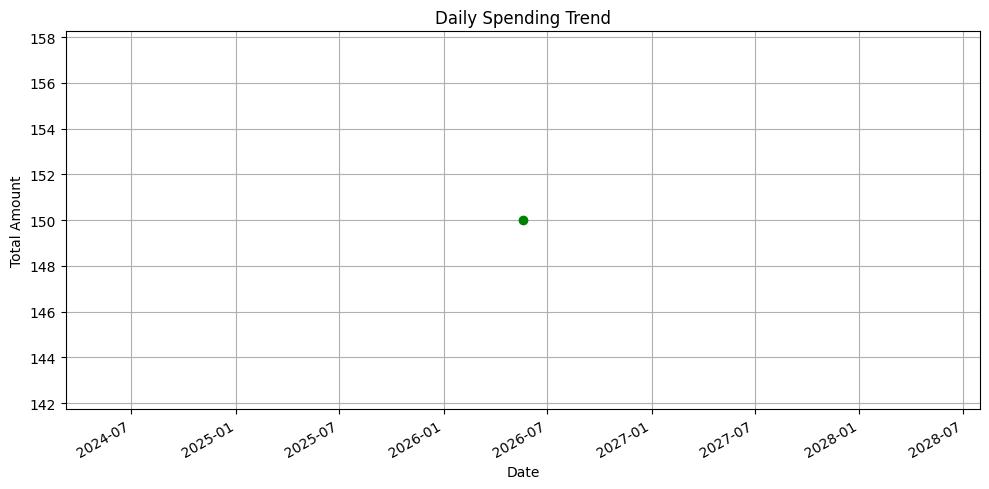


    PERSONAL EXPENSE TRACKER
1. Add Expense
2. View All Expenses
3. Category Summary (Bar Chart)
4. Daily Spending Trend (Line Chart)
5. Exit

--- Add New Expense ---
✅ Expense added successfully!

    PERSONAL EXPENSE TRACKER
1. Add Expense
2. View All Expenses
3. Category Summary (Bar Chart)
4. Daily Spending Trend (Line Chart)
5. Exit


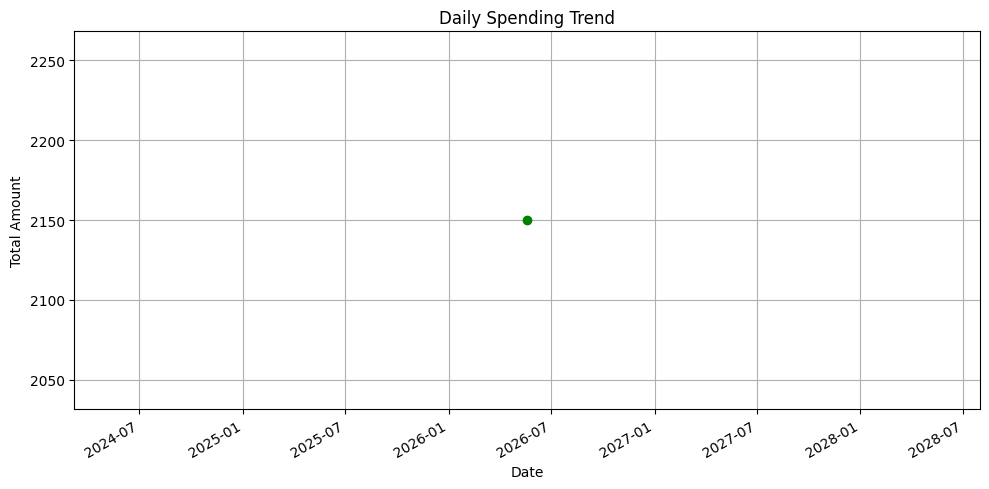


    PERSONAL EXPENSE TRACKER
1. Add Expense
2. View All Expenses
3. Category Summary (Bar Chart)
4. Daily Spending Trend (Line Chart)
5. Exit

--- Spending by Category ---
Category
shopping    2000.0
Food         150.0
Name: Amount, dtype: float64


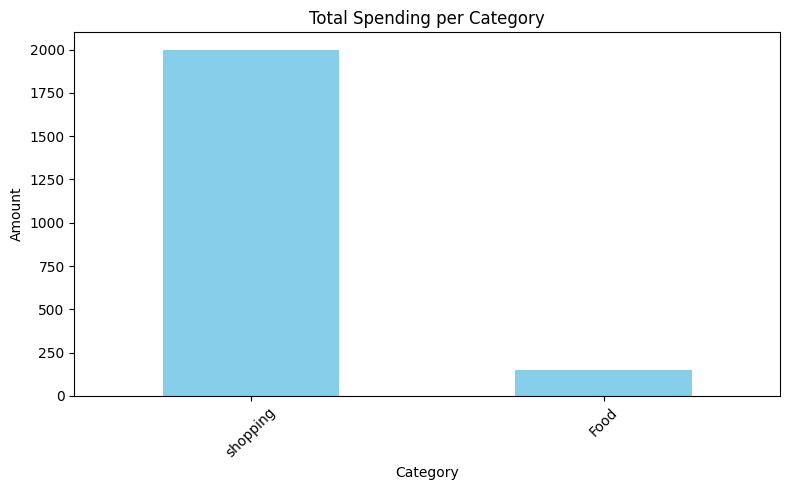


    PERSONAL EXPENSE TRACKER
1. Add Expense
2. View All Expenses
3. Category Summary (Bar Chart)
4. Daily Spending Trend (Line Chart)
5. Exit
Goodbye! Keep saving. 👋


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import os

CSV_FILE = "expenses.csv"

def initialize_csv():
    """Create the CSV file with headers if it doesn't exist."""
    if not os.path.exists(CSV_FILE):
        df = pd.DataFrame(columns=["Date", "Category", "Description", "Amount"])
        df.to_csv(CSV_FILE, index=False)

def add_expense():
    """Add a new expense record."""
    print("\n--- Add New Expense ---")
    date = input("Date (YYYY-MM-DD, or press Enter for today): ")
    if not date:
        date = datetime.today().strftime("%Y-%m-%d")
    category = input("Category (e.g., Food, Transport, Shopping): ").strip()
    description = input("Description: ").strip()
    try:
        amount = float(input("Amount (in INR or your currency): "))
    except ValueError:
        print("Invalid amount. Expense not added.")
        return

    new_entry = pd.DataFrame([[date, category, description, amount]],
                             columns=["Date", "Category", "Description", "Amount"])
    new_entry.to_csv(CSV_FILE, mode='a', header=False, index=False)
    print("✅ Expense added successfully!")

def view_expenses():
    """Display all expenses as a table."""
    if not os.path.exists(CSV_FILE):
        print("No expenses found. Add some first.")
        return
    df = pd.read_csv(CSV_FILE)
    if df.empty:
        print("No expenses recorded.")
    else:
        print("\n--- All Expenses ---")
        print(df.to_string(index=False))

def category_summary():
    """Show total spending per category as a bar chart."""
    if not os.path.exists(CSV_FILE):
        print("No data available.")
        return
    df = pd.read_csv(CSV_FILE)
    if df.empty:
        print("No expenses to summarize.")
        return

    category_totals = df.groupby("Category")["Amount"].sum().sort_values(ascending=False)
    print("\n--- Spending by Category ---")
    print(category_totals)

    # Plot bar chart
    plt.figure(figsize=(8, 5))
    category_totals.plot(kind='bar', color='skyblue')
    plt.title("Total Spending per Category")
    plt.xlabel("Category")
    plt.ylabel("Amount")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def daily_trend():
    """Plot daily total spending (line chart)."""
    if not os.path.exists(CSV_FILE):
        print("No data available.")
        return
    df = pd.read_csv(CSV_FILE)
    if df.empty:
        print("No expenses to plot.")
        return

    df["Date"] = pd.to_datetime(df["Date"])
    daily = df.groupby("Date")["Amount"].sum().sort_index()

    plt.figure(figsize=(10, 5))
    daily.plot(kind='line', marker='o', color='green')
    plt.title("Daily Spending Trend")
    plt.xlabel("Date")
    plt.ylabel("Total Amount")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def main():
    initialize_csv()
    while True:
        print("\n" + "="*40)
        print("    PERSONAL EXPENSE TRACKER")
        print("="*40)
        print("1. Add Expense")
        print("2. View All Expenses")
        print("3. Category Summary (Bar Chart)")
        print("4. Daily Spending Trend (Line Chart)")
        print("5. Exit")
        choice = input("Enter your choice (1-5): ")

        if choice == "1":
            add_expense()
        elif choice == "2":
            view_expenses()
        elif choice == "3":
            category_summary()
        elif choice == "4":
            daily_trend()
        elif choice == "5":
            print("Goodbye! Keep saving. 👋")
            break
        else:
            print("Invalid choice. Please try again.")

if __name__ == "__main__":
    main()